# Word Embeddings

## Word2Vec


Word2Vec is a popular technique in NLP for converting words into numerical vectors (also known as embeddings), where words with similar meanings are represented by similar vectors.

Word2Vec is trained to adjust the vectors of words so that words appearing in similar contexts have similar vector representations. It can be trained using two main architectures:

*   Skip-Gram — Predicts context words from a target word.
*   Continuous Bag of Words (CBOW) — Predicts the target word from context words.

Word2Vec is a neural network-based model that learns word embeddings by predicting context words from a target word (Skip-Gram) or a target word from context words (CBOW). It uses a feed-forward neural network with an input layer (one-hot encoded word), a hidden layer (word embeddings), and an output layer (context words). During training, the model adjusts weights using backpropagation and gradient descent to minimize prediction error. The resulting embeddings capture semantic relationships, where words in similar contexts have similar representations.

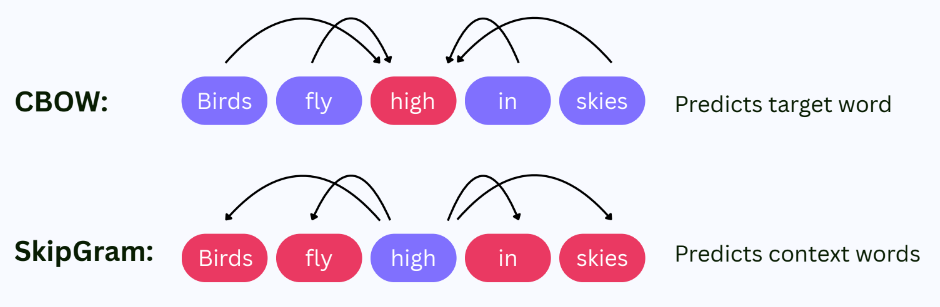


In [ ]:
# Libraries

!pip install gensim
import gensim
from gensim.models import Word2Vec

In [ ]:
# Corpus
corpus = [
    "Cats chase mice in the garden.",
    "Dogs bark loudly at night.",
    "Birds sing sweet songs every morning.",
    "The cat sleeps on the warm sofa.",
    "A fast dog chased the red ball.",
    "Mice hide quickly when cats appear.",
]

In [ ]:
sentences = [sentence.lower().split() for sentence in corpus]
sentences

[['cats', 'chase', 'mice', 'in', 'the', 'garden.'],
 ['dogs', 'bark', 'loudly', 'at', 'night.'],
 ['birds', 'sing', 'sweet', 'songs', 'every', 'morning.'],
 ['the', 'cat', 'sleeps', 'on', 'the', 'warm', 'sofa.'],
 ['a', 'fast', 'dog', 'chased', 'the', 'red', 'ball.'],
 ['mice', 'hide', 'quickly', 'when', 'cats', 'appear.']]

In [ ]:
model = Word2Vec(vector_size=10, window=3, sg=1, min_count=1)


*   vector_size = Dimension of each word vector (how many features each word is represented by)
*   window = Context window size — number of words to the left and right considered as context.
*   sg=1 = Training algorithm; 1 = Skip-Gram | 0 = CBOW
*   min_count = Ignores words that appear fewer times than this threshold in the corpus.

In [ ]:
# Build vocabulary
voc = model.build_vocab(sentences)

In [ ]:
# Train the model
model.train(sentences, total_examples=len(sentences), epochs=10)


(75, 370)

In [ ]:
# Get word vector for 'cats'

cats_vector = model.wv['cats']
print("Word Vector for 'cats':", cats_vector)
print("---------------------------------------------------------------------------------------------------")

# Get word vector for 'dogs'

dogs_vector = model.wv['dogs']
print("Word Vector for 'dogs':", dogs_vector)
print("---------------------------------------------------------------------------------------------------")

# Get word vector for 'mice'

mice_vector = model.wv['mice']
print("Word Vector for 'mice':", mice_vector)

Word Vector for 'cats': [ 0.07307888  0.05075055  0.06751923  0.00755519  0.06354158 -0.03401349
 -0.00944893  0.05774654 -0.07523876 -0.03930302]
---------------------------------------------------------------------------------------------------
Word Vector for 'dogs': [ 0.01217502 -0.08458303 -0.0822377  -0.00230556  0.01236892 -0.05743888
 -0.04724409 -0.07344445  0.08327902  0.00121991]
---------------------------------------------------------------------------------------------------
Word Vector for 'mice': [ 0.07379718 -0.01532843 -0.04537288  0.0655283  -0.04859158 -0.01815514
  0.02875209  0.00993615 -0.08286157 -0.09448049]


**Cosine similarity** measures how similar two vectors are by calculating the cosine of the angle between them. It is commonly used in text similarity, word embeddings, and recommendation systems.

*   1 → Vectors are identical (same direction)
*   0 → Vectors are orthogonal (unrelated)
*   -1 → Vectors are opposite (completely different)

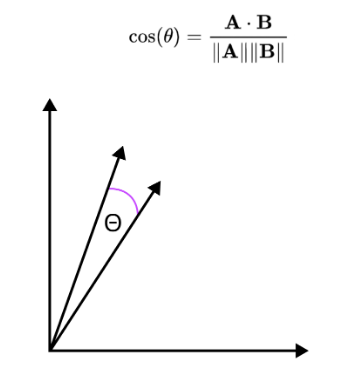


In [ ]:
# Libraries

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Cosine similarity between 'cats' and 'dogs'

cat_dog = cosine_similarity([cats_vector], [dogs_vector])
print(cat_dog )
print(f"Cosine Similarity between 'cats' and 'dogs': {cat_dog[0][0]}")
print("-----------------------------------------------------------------")

# Cosine similarity between 'cats' and 'mice'

cat_mice = cosine_similarity([cats_vector], [mice_vector])
print(cat_mice)
print(f"Cosine Similarity between 'cats' and 'mice': {cat_mice[0][0]}")

[[-0.5417753]]
Cosine Similarity between 'cats' and 'dogs': -0.5417752861976624
-----------------------------------------------------------------
[[0.32909018]]
Cosine Similarity between 'cats' and 'mice': 0.3290901780128479


##GloVe

GloVe (Global Vectors for Word Representation) is a word embedding model that learns vector representations of words based on their global co-occurrence statistics in a large corpus.  Unlike some models that only look at words nearby, GloVe looks at how often words appear together in the entire collection of text (the whole corpus).

The pretrained GloVe model is available in various sizes (e.g., 50D, 100D, 200D, 300D) and is trained on large corpora like Wikipedia, Common Crawl, etc. The model is stored in text files, with each line containing a word and its corresponding vector. These pretrained embeddings are ready to use directly for various NLP tasks like similarity calculation, text classification, or sentiment analysis.

GloVe Documentation: https://nlp.stanford.edu/projects/glove/

In [ ]:
# Libraries

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Save GloVe File in Drive

glove_file = '/content/drive/MyDrive/glove.6B.50d.txt'

In [ ]:
# Load the GloVe vectors from file

def load_glove_model(glove_file):
    word_vectors = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            word_vectors[word] = vector
    return word_vectors

# Load the pretrained GloVe embeddings

glove_model = load_glove_model(glove_file)


In [ ]:
# Get word vector for 'cat'

cat_vector = glove_model['cat']
print("Word Vector for 'cat':", cat_vector)
print("-----------------------------------------------------------------------------------------------")

# Get word vector for 'dog'

dog_vector = glove_model['dog']
print("Word Vector for 'dog':", dog_vector)
print("-----------------------------------------------------------------------------------------------")

# Get word vector for 'mice'

mice_vector = glove_model['mice']
print("Word Vector for 'mice':", mice_vector)

Word Vector for 'cat': [ 0.45281  -0.50108  -0.53714  -0.015697  0.22191   0.54602  -0.67301
 -0.6891    0.63493  -0.19726   0.33685   0.7735    0.90094   0.38488
  0.38367   0.2657   -0.08057   0.61089  -1.2894   -0.22313  -0.61578
  0.21697   0.35614   0.44499   0.60885  -1.1633   -1.1579    0.36118
  0.10466  -0.78325   1.4352    0.18629  -0.26112   0.83275  -0.23123
  0.32481   0.14485  -0.44552   0.33497  -0.95946  -0.097479  0.48138
 -0.43352   0.69455   0.91043  -0.28173   0.41637  -1.2609    0.71278
  0.23782 ]
-----------------------------------------------------------------------------------------------
Word Vector for 'dog': [ 0.11008   -0.38781   -0.57615   -0.27714    0.70521    0.53994
 -1.0786    -0.40146    1.1504    -0.5678     0.0038977  0.52878
  0.64561    0.47262    0.48549   -0.18407    0.1801     0.91397
 -1.1979    -0.5778    -0.37985    0.33606    0.772      0.75555
  0.45506   -1.7671    -1.0503     0.42566    0.41893   -0.68327
  1.5673     0.27685   -0.61708

In [ ]:
# Cosine similarity between 'cat' and 'dog'

cat_dog = cosine_similarity([cat_vector], [dog_vector])
print(cat_dog)
print(f"Cosine Similarity between 'cat' and 'dog': {cat_dog[0][0]}")
print("-----------------------------------------------------------------")

# Cosine similarity between 'cat' and 'mice'

cat_mice = cosine_similarity([cat_vector], [mice_vector])
print(cat_mice)
print(f"Cosine Similarity between 'cats' and 'mice': {cat_mice[0][0]}")
print("-----------------------------------------------------------------")

# Cosine similarity between 'dog' and 'mice'

dog_mice = cosine_similarity([dog_vector], [mice_vector])
print(dog_mice)
print(f"Cosine Similarity between 'dog' and 'mice': {dog_mice[0][0]}")

[[0.92180055]]
Cosine Similarity between 'cat' and 'dog': 0.9218005537986755
-----------------------------------------------------------------
[[0.5828184]]
Cosine Similarity between 'cats' and 'mice': 0.5828183889389038
[[0.5128297]]
Cosine Similarity between 'dog' and 'mice': 0.5128297209739685


# Sequence Models

In [ ]:
# Libraries

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## Dataset Loading and Pre-processing

In [ ]:
from datasets import load_dataset

# Load the TweetEval sentiment dataset

dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
dataset["train"][0] # 0 = negative, 1 = neutral, 2 = positive

{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"',
 'label': 2}

In [ ]:
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

val_texts = dataset["validation"]["text"]
val_labels = dataset["validation"]["label"]

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Tokenizer

num_words = 10000

tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>") # Only keep top 10,000 most frequent words
tokenizer.fit_on_texts(train_texts) # Scans all text, counts frequencies, assigns each word a unique integer ID: 0 = PAD, 1 = OOV, 2 to 9999 = words

In [ ]:
# Convert text to sequences using the mapping: 0 = PAD, 1 = OOV, 2 to 9999 = words

X_train = tokenizer.texts_to_sequences(train_texts)
X_val   = tokenizer.texts_to_sequences(val_texts)
X_test  = tokenizer.texts_to_sequences(test_texts)

In [ ]:
X_train[0]

[9020,
 4,
 5,
 2,
 1314,
 1826,
 10,
 2,
 292,
 407,
 7552,
 7553,
 5185,
 2,
 1715,
 10,
 1,
 1]

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pad sequences to fixed length as neural networks need inputs to be the same shape (like a matrix).

max_len = 50

X_train = pad_sequences(X_train, maxlen=max_len, padding="post")
X_val   = pad_sequences(X_val, maxlen=max_len, padding="post")
X_test  = pad_sequences(X_test, maxlen=max_len, padding="post")

In [ ]:
X_train[0]

array([9020,    4,    5,    2, 1314, 1826,   10,    2,  292,  407, 7552,
       7553, 5185,    2, 1715,   10,    1,    1,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0], dtype=int32)

In [ ]:
# Labels

y_train = np.array(train_labels)
y_val = np.array(val_labels)
y_test = np.array(test_labels)

In [ ]:
y_train # 0 = negative, 1 = neutral, 2 = positive

array([2, 1, 1, ..., 2, 1, 1])

## Training and Evaluation

### Simple RNN & Bidirectional RNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

# Simple RNN Classifier

with tf.device('/GPU:0'):
    model = Sequential([
        Embedding(input_dim=num_words, output_dim=32, input_length=max_len), # Builds embedding matrix of 10,000 x 32 and map each word in a 50-word sentence into a 32 dim vector
        SimpleRNN(32),
        Dropout(0.5), # Dropout for regularization
        Dense(3, activation='softmax') # 3 classes, softmax output
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy', # For multi-class labels in integer format (not one-hot encoded)
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_val, y_val)
    )

    test_loss, test_acc = model.evaluate(X_test, y_test)
    print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.4518 - loss: 1.0161 - val_accuracy: 0.4890 - val_loss: 0.9896
Epoch 2/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.5630 - loss: 0.9126 - val_accuracy: 0.5725 - val_loss: 0.9114
Epoch 3/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.6640 - loss: 0.7736 - val_accuracy: 0.5945 - val_loss: 0.8830
Epoch 4/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.7383 - loss: 0.6445 - val_accuracy: 0.5955 - val_loss: 0.9272
Epoch 5/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7927 - loss: 0.5389 - val_accuracy: 0.5705 - val_loss: 1.0132
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5239 - loss: 1.1300
Test Accuracy: 0.5238521695137024


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 966,539 (3.69 MB)

 Trainable params: 322,179 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644,360 (2.46 MB)

### LSTM & Bidirectional LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# LSTM Classifier

with tf.device('/GPU:0'):
    model = Sequential([
        Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
        LSTM(32),
        Dropout(0.5), # Dropout for regularization
        Dense(3, activation='softmax') # 3 classes, softmax output
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_val, y_val)
    )

    test_loss, test_acc = model.evaluate(X_test, y_test)
    print("Test Accuracy:", test_acc)

Epoch 1/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.4395 - loss: 1.0230 - val_accuracy: 0.4345 - val_loss: 1.0187
Epoch 2/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step - accuracy: 0.4541 - loss: 0.9931 - val_accuracy: 0.4965 - val_loss: 0.9439
Epoch 3/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.5591 - loss: 0.8576 - val_accuracy: 0.6110 - val_loss: 0.8436
Epoch 4/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.6806 - loss: 0.7364 - val_accuracy: 0.6455 - val_loss: 0.7721
Epoch 5/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.7266 - loss: 0.6627 - val_accuracy: 0.6520 - val_loss: 0.7604
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5970 - loss: 0.8827
Test Accuracy: 0.5970367789268494


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 985,259 (3.76 MB)

 Trainable params: 328,419 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 656,840 (2.51 MB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# Bidirectional-LSTM Classifier

with tf.device('/GPU:0'):
    model = Sequential([
        Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
        Bidirectional(LSTM(32)),
        Dropout(0.5), # Dropout for regularization
        Dense(3, activation='softmax') # 3 classes, softmax output
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_val, y_val)
    )

    test_loss, test_acc = model.evaluate(X_test, y_test)
    print("Test Accuracy:", test_acc)

Epoch 1/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.5872 - loss: 0.8637 - val_accuracy: 0.6515 - val_loss: 0.7591
Epoch 2/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.6970 - loss: 0.6861 - val_accuracy: 0.6755 - val_loss: 0.7347
Epoch 3/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.7324 - loss: 0.6220 - val_accuracy: 0.6785 - val_loss: 0.7430
Epoch 4/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.7563 - loss: 0.5727 - val_accuracy: 0.6795 - val_loss: 0.7788
Epoch 5/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.7785 - loss: 0.5261 - val_accuracy: 0.6610 - val_loss: 0.8309
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5918 - loss: 0.9919
Test Accuracy: 0.5918267369270325


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,010,507 (3.85 MB)

 Trainable params: 336,835 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 673,672 (2.57 MB)

### GRU & Bidirectional GRU

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

# GRU Classifier

with tf.device('/GPU:0'):
    model = Sequential([
        Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
        GRU(32),
        Dropout(0.5), # Dropout for regularization
        Dense(3, activation='softmax') # 3 classes, softmax output
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_val, y_val)
    )

    test_loss, test_acc = model.evaluate(X_test, y_test)
    print("Test Accuracy:", test_acc)

Epoch 1/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.4440 - loss: 1.0209 - val_accuracy: 0.4345 - val_loss: 1.0193
Epoch 2/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.4545 - loss: 0.9947 - val_accuracy: 0.5515 - val_loss: 0.9016
Epoch 3/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.6463 - loss: 0.7682 - val_accuracy: 0.6880 - val_loss: 0.7248
Epoch 4/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.7186 - loss: 0.6486 - val_accuracy: 0.6810 - val_loss: 0.7297
Epoch 5/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7590 - loss: 0.5755 - val_accuracy: 0.6790 - val_loss: 0.7653
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6031 - loss: 0.8981
Test Accuracy: 0.6031423211097717


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 979,307 (3.74 MB)

 Trainable params: 326,435 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 652,872 (2.49 MB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional

# Bidirectional-GRU Classifier

with tf.device('/GPU:0'):
    model = Sequential([
        Embedding(input_dim=num_words, output_dim=32, input_length=max_len),
        Bidirectional(GRU(32)),
        Dropout(0.5), # Dropout for regularization
        Dense(3, activation='softmax') # 3 classes, softmax output
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_val, y_val)
    )

    test_loss, test_acc = model.evaluate(X_test, y_test)
    print("Test Accuracy:", test_acc)

Epoch 1/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 54s 68ms/step - accuracy: 0.5828 - loss: 0.8763 - val_accuracy: 0.6505 - val_loss: 0.7696
Epoch 2/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 51s 71ms/step - accuracy: 0.6940 - loss: 0.6977 - val_accuracy: 0.6820 - val_loss: 0.7346
Epoch 3/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 79s 67ms/step - accuracy: 0.7297 - loss: 0.6281 - val_accuracy: 0.6720 - val_loss: 0.7581
Epoch 4/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 49s 68ms/step - accuracy: 0.7533 - loss: 0.5806 - val_accuracy: 0.6680 - val_loss: 0.7670
Epoch 5/5
713/713 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.7760 - loss: 0.5382 - val_accuracy: 0.6590 - val_loss: 0.8046
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5786 - loss: 0.9824
Test Accuracy: 0.5785574913024902


In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        12,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 998,603 (3.81 MB)

 Trainable params: 332,867 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 665,736 (2.54 MB)